In [1]:
import os
import os.path as osp
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
from scipy.stats import t
from scipy.optimize import curve_fit

from panda.interface import *
import panda.interface
from panda.profile_approx import profile_approx, profile_approx_from_array
from panda.density_profile import get_density_profile
import time
from tqdm import tqdm
from scipy import stats
# from src.utils_py.stat_ineff import get_statistical_inefficiency
# from src.utils_py.angle_blocks import get_angle_blocks

cmap = matplotlib.colormaps['tab10']
# plt.rcParams['font.family'] = 'Helvetica'

In [2]:
# Load Helvetica font from file
root = os.environ['HOME']
font_path = f"{root}/HelveticaNeue.ttc"  # Update this path
helvetica_font = fm.FontProperties(fname=font_path)

---

In [3]:
len(en)

NameError: name 'en' is not defined

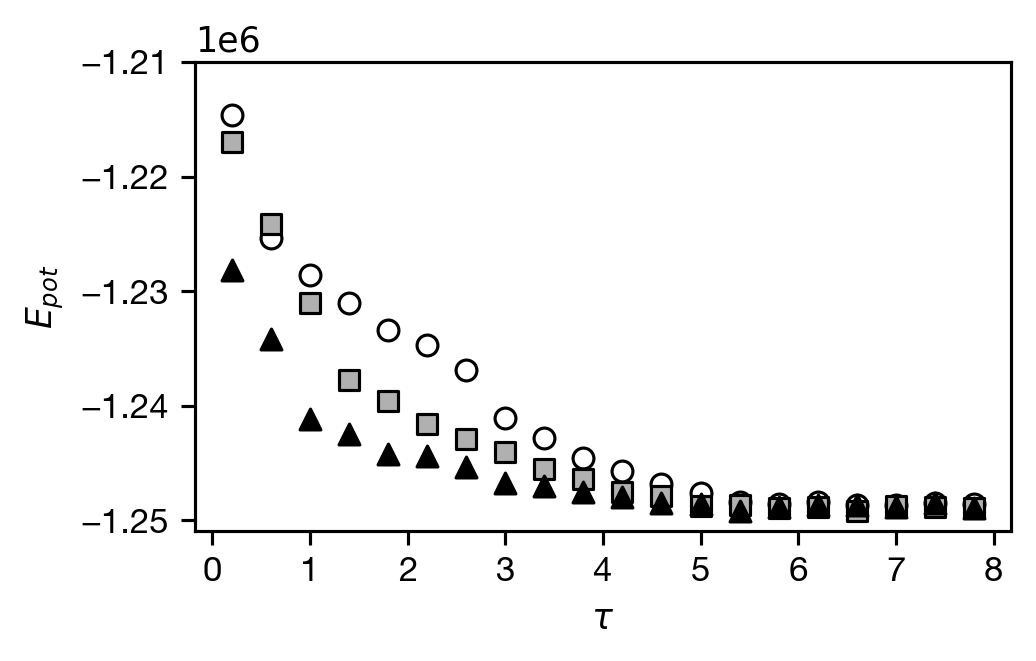

In [3]:
# --- Improved grayscale, vector-friendly, publication-ready plot ---

# Constants for publication quality
DPI = 250  # 250 dpi at 100% magnification
MM_TO_INCH = 1 / 25.4
MIN_LINEWIDTH_MM = 0.16 * 2
MIN_LINEWIDTH_PT = MIN_LINEWIDTH_MM * 72 / 25.4  # Convert mm to points for matplotlib
MIN_MARKER_DIST_MM = 0.2  # Minimum white field between objects

scale = 1.0
fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=DPI, facecolor='white')

def block_average(arr, block_size):
    n_blocks = len(arr) // block_size
    arr = arr[:n_blocks * block_size]
    return arr.reshape(n_blocks, block_size).mean(axis=1)

def block_average_time(t, arr, block_size):
    n_blocks = len(arr) // block_size
    t = t[:n_blocks * block_size]
    arr = arr[:n_blocks * block_size]
    t_blocks = t.reshape(n_blocks, block_size).mean(axis=1)
    arr_blocks = arr.reshape(n_blocks, block_size).mean(axis=1)
    return t_blocks, arr_blocks

end = 2000
block_size = 100  # You can adjust this for desired smoothing

# Grayscale: 95% black is #0D0D0D (hex), but for lines, just use 'black' for max contrast
# Use only black, dark gray, and white for markers, no dot coloring
markers = ['o', 's', '^', 'v', '*']
marker_facecolors = ['white', '#B0B0B0', 'black']  # white, light gray, black
# marker_facecolors = ['white', '#999999', '#5b5b5b', 'black']  # white, light gray, black
# '#B0B0B0'
marker_edgecolors = ['black', 'black', 'black', 'black', 'black']
marker_sizes = [36, 36, 36, 36, 36]  # marker size in points^2, large enough for 0.2mm separation
# markers = ['o', 's', '^', '*']
# marker_facecolors = ['white', '#B0B0B0', 'black', 'black']  # white, light gray, black
# marker_edgecolors = ['black', 'black', 'black', 'black']
# marker_sizes = [36, 36, 36, 36]  # marker size in points^2, large enough for 0.2mm separation


for i, sc in enumerate(['0.0', '0.1', '0.3']):
    folder = f'/home/fluffymelon/PANDA_exp/wetting/cal_decane_tip4p_{sc}'

    t, en = np.loadtxt(osp.join(folder, "pot_energy.xvg"), comments=["@", "#"], unpack=True)
    t = t[:end] * 2 / 1000
    en = en[:end]
    t_blocks, en_blocks = block_average_time(t, en, block_size)
    # Use only edge and face color, no dot coloring, no alpha
    ax.scatter(
        t_blocks, en_blocks,
        s=marker_sizes[i],
        marker=markers[i],
        edgecolors=marker_edgecolors[i],
        facecolors=marker_facecolors[i],
        linewidths=MIN_LINEWIDTH_PT,
        zorder=i+5
    )

# Remove grid and background
ax.set_facecolor('white')
ax.grid(False)

# Set axis line thickness
for spine in ax.spines.values():
    spine.set_linewidth(MIN_LINEWIDTH_PT)

# Set ticks and tick parameters for minimum line thickness and font
xticks = np.arange(0, 9, 1, dtype=int)
ax.set_xticks(xticks)

# Set ticks and tick parameters for minimum line thickness and font
yticks = np.arange(-1.25e6, -1.205e6, 0.01e6)
ax.set_yticks(yticks)

ax.tick_params(axis='both', which='both', width=MIN_LINEWIDTH_PT, length=4, direction='out', color='black', labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica_font)

# Remove axis labels and legend (no captions per instructions)
ax.set_xlabel(r"$\tau$", fontsize=10)
ax.set_ylabel(r"$E_{pot}$", fontsize=10)
ax.legend_.remove() if ax.get_legend() is not None else None

plt.tight_layout(pad=0.2)
plt.show()

---

In [4]:
scales = ['0.0', '0.1', '0.3']

In [14]:
folder = f'{root}/PANDA_exp/wetting/'

args = {
    # "trajectory_file": os.path.join(folder, 'cal_dec_tip4p.xtc'),
    # "topology_file": os.path.join(folder, 'cal_dec_tip4p.gro'),
    "residue": 'DECAN',
    "sl": 200,
    "chunk_length": 1_000,
    "begin_time": 0,
    "time": 40_000,
    "timestep": 2,
    "units": 'ps',
}

for sc in scales:
    print(f'Processing {sc}...')
    args['trajectory_file'] = os.path.join(folder, f'cal_decane_tip4p_{sc}/cal_decane_tip4p.xtc')
    args['topology_file'] = os.path.join(folder, f'cal_decane_tip4p_{sc}/cal_decane_tip4p.gro')


    # axises = np.load(osp.join(folder, 'axises.npy'))
    # denses = np.load(osp.join(folder, 'denses.npy'))
    axises, denses = get_density_profile(**args)

    np.save(os.path.join(folder, f'cal_decane_tip4p_{sc}', 'axises'), axises)
    np.save(os.path.join(folder, f'cal_decane_tip4p_{sc}', 'denses'), denses)


Processing 0.1...


Chunk:   0%|          | 0/40 [00:00<?, ?it/s]

Chunk: 100%|██████████| 40/40 [04:54<00:00,  7.36s/it]


Processing 0.3...


Chunk: 100%|██████████| 40/40 [04:23<00:00,  6.58s/it]


In [5]:
### Decane ###

folder = f'{root}/PANDA_exp/wetting/'

args = {
    # "trajectory_file": os.path.join(folder, 'cal_dec_tip4p.xtc'),
    # "topology_file": os.path.join(folder, 'cal_dec_tip4p.gro'),
    "residue": 'DECAN',
    "H": 6,
    "l": 12.00282 / 6,
    "phi": 0.5,
    "rho_bulk": 3.0896 * 10,
    "interface_type": 'roll',
    "sl": 200,
    "block_length": 1_000,
    "chunk_length": 1_000,
    "begin_time": 0,
    "time": 40_000,
    "timestep": 2,
    "units": 'ps',
}

angles = []
delta = []
mae = []

# times = []
# for n_jobs in [1, 2, 4, 8, 16]:
for sc in scales:
    print(f'Processing {sc}...')
    start = time.perf_counter()
    axises = np.load(os.path.join(folder, f'cal_decane_tip4p_{sc}', 'axises.npy'))
    denses = np.load(os.path.join(folder, f'cal_decane_tip4p_{sc}', 'denses.npy'))

    # Averaging axises and denses arrays by blocks
    blocks_num = axises.shape[0] // args["block_length"]

    mean_axises = np.zeros((blocks_num, axises.shape[1]))
    mean_denses = np.zeros((blocks_num, denses.shape[1]))
    for i in range(blocks_num):
        mean_axises[i, :] = np.mean(axises[(i * args["block_length"]):((i+1) * args["block_length"]), :], axis=0)
        mean_denses[i, :] = np.mean(denses[(i * args["block_length"]):((i + 1) * args["block_length"]), :], axis=0)


    delta_array = np.zeros(blocks_num)
    mae_array = np.zeros(blocks_num)

    normalized_axises = np.zeros((blocks_num, axises.shape[1]))
    normalized_denses = np.zeros((blocks_num, denses.shape[1]))
    for i in tqdm(range(blocks_num)):
        axis_i, dens_i, result = profile_approx_from_array(
            mean_denses[i, :],
            mean_axises[i, :],
            args["rho_bulk"],
            args["l"],
            args["phi"],
            args["H"],
            interface_type=args["interface_type"],
            samples=100,
            extention='delta',
            n_jobs=8,
            display=False
        )

        normalized_axises[i, :] = axis_i
        normalized_denses[i, :] = dens_i

        # angles_alpha[i] = result_alpha['theta']
        delta_array[i] = result['delta']
        mae_array[i] = result['mae']

        # -----------
        # scale = 1.0
        # # Visualisation of density profile with different PANDA algorithm version
        # # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), dpi=300)
        # # fig, ax = plt.subplots(figsize=(4*scale, 3*scale), dpi=300)
        # fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=300)

        # def findvalue(seq, val, rtol=0.05):    # value that works for your example
        #     return np.where(np.isclose(seq, val, rtol=rtol))[0]

        # offset = len(normalized_axises[i, :])- findvalue(normalized_axises[i, :], 0.6, 0.01)[0]

        # ax.grid(alpha=0.5)
        # ax.plot(
        #     normalized_axises[i, offset:-offset], normalized_denses[i, offset:-offset],
        #     label=r'$n$-decane',
        #     color='#DF2E38',
        #     linewidth=2.5
        # )

        # rho_alpha = getattr(panda.interface, f"rho_roll_delta")

        # ax.plot(
        #     normalized_axises[i, offset:-offset], rho_alpha(normalized_axises[i, offset:-offset], args["l"], args["phi"], delta_alpha[i]),
        #     # label=r'approximation with $\theta$ = {:.1f}$^\circ$'.format(np.rad2deg(angles_alpha[i])),
        #     color='#000000',
        #     linewidth=3,
        #     linestyle='dashed'
        # )


        # xticks = np.round(np.arange(-0.6, 0.61, 0.3), 1)
        # # ax.xaxis.set_major_locator(FixedLocator(xticks))
        # ax.set_xticks(xticks, labels=xticks, fontproperties=helvetica_font, fontsize=12)
        # ax.set_xlabel('z', fontproperties=helvetica_font, fontsize=14)

        # yticks = np.round(np.arange(0, 1.01, 0.2), 1)
        # ax.set_yticks(yticks, labels=yticks, fontproperties=helvetica_font, fontsize=12)
        # ax.set_ylabel(r'$\rho / \rho_{bulk}$', fontproperties=helvetica_font, fontsize=14)

        # ax.legend(loc='best', prop=helvetica_font, fontsize=12)

        # plt.show()
        # -----------

    # angles.append(angles_alpha)
    delta.append(delta_array)
    mae.append(mae_array)
    print(f'Processing {sc} took {time.perf_counter() - start} seconds')

    # np.save('../decane_angles_checkpoint', angles)
    # np.save('../decane_delta_checkpoint', delta)

# times.append(time.perf_counter() - start)
delta = np.array(delta)
mae = np.array(mae)

np.save('../data/decane_wetting_layer', delta)

Processing 0.0...


100%|██████████| 20/20 [00:08<00:00,  2.31it/s]


Processing 0.0 took 9.85517262481153 seconds
Processing 0.1...


100%|██████████| 20/20 [00:08<00:00,  2.28it/s]


Processing 0.1 took 9.91118496377021 seconds
Processing 0.3...


100%|██████████| 20/20 [00:08<00:00,  2.31it/s]

Processing 0.3 took 9.916802460327744 seconds


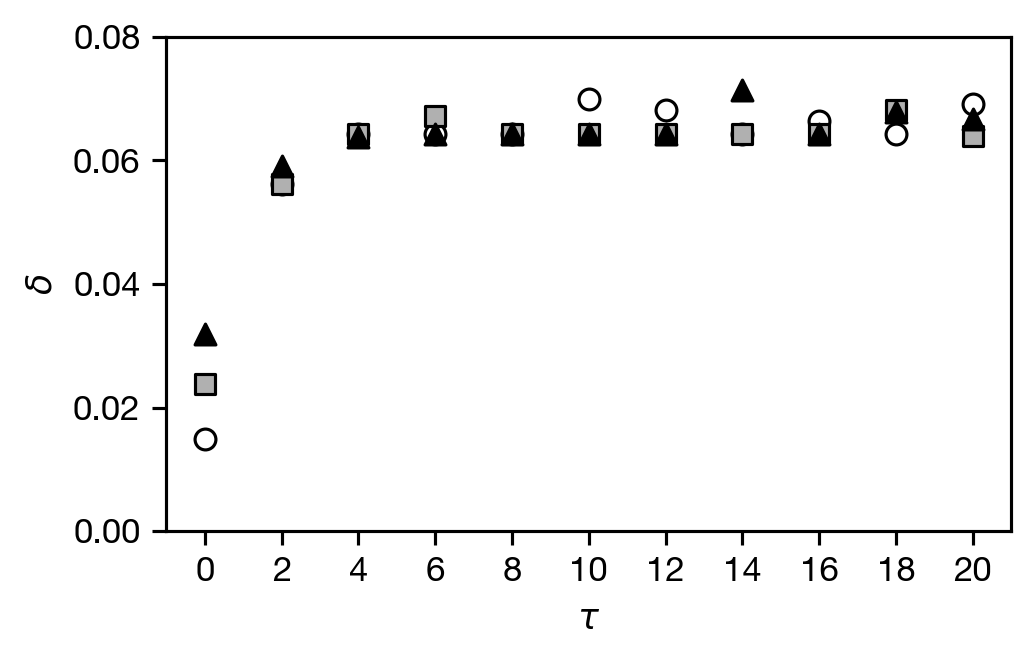

In [6]:
# --- Improved grayscale, vector-friendly, publication-ready plot ---

import matplotlib.pyplot as plt
import numpy as np

# Constants for publication quality
DPI = 250  # 250 dpi at 100% magnification
MM_TO_INCH = 1 / 25.4
MIN_LINEWIDTH_MM = 0.16 * 2
MIN_LINEWIDTH_PT = MIN_LINEWIDTH_MM * 72 / 25.4  # Convert mm to points for matplotlib
MIN_MARKER_DIST_MM = 0.2  # Minimum white field between objects

# Grayscale: 95% black is #0D0D0D (hex), but for lines, just use 'black' for max contrast
# Use only black, dark gray, and white for markers, no dot coloring
markers = ['o', 's', '^', '*']
marker_facecolors = ['white', '#B0B0B0', 'black']  # white, light gray, black
marker_edgecolors = ['black', 'black', 'black']
marker_sizes = [36, 36, 36]  # marker size in points^2, large enough for 0.2mm separation

scale = 1.0
fig, ax = plt.subplots(figsize=(4*scale, 2.5*scale), dpi=DPI, facecolor='white')

end = 11

for i in range(len(delta)):
    # Use only edge and face color, no dot coloring, no alpha
    ax.scatter(
        range(0, 2*end, 2), delta[i][:end],
        # range(0, 2*end, 2), delta[i][:end] * 6,
        s=marker_sizes[i % len(marker_sizes)],
        marker=markers[i % len(markers)],
        edgecolors=marker_edgecolors[i % len(marker_edgecolors)],
        facecolors=marker_facecolors[i % len(marker_facecolors)],
        linewidths=MIN_LINEWIDTH_PT,
        zorder=i+5
    )

# Remove grid and background
ax.set_facecolor('white')
ax.grid(False)

# Set axis line thickness
for spine in ax.spines.values():
    spine.set_linewidth(MIN_LINEWIDTH_PT)

# Set ticks and tick parameters for minimum line thickness and font
xticks = np.arange(0, 2*end, 2, dtype=int)
ax.set_xticks(xticks)
yticks = np.arange(0, 0.081, 0.02)
ax.set_yticks(yticks)
ax.tick_params(axis='both', which='both', width=MIN_LINEWIDTH_PT, length=4, direction='out', color='black', labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    if 'helvetica_font' in globals():
        label.set_fontproperties(helvetica_font)

# Set ticks and tick parameters for minimum line thickness and font
# yticks = np.arange(0.01, 0.081, 0.01)
# ax.set_yticks(yticks)

# Remove axis labels and legend (no captions per instructions)
ax.set_xlabel(r"$\tau$", fontsize=10)
ax.set_ylabel(r"$\delta$", fontsize=10)
ax.legend_.remove() if ax.get_legend() is not None else None

plt.tight_layout(pad=0.2)
plt.show()

In [14]:
len(delta[0])

20

Text(0.5, 0, 'time, ns')

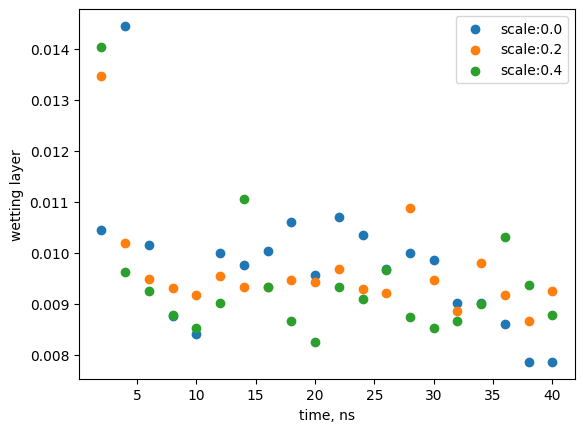

In [23]:
for i in range(len(mae)):
    # plt.scatter(range(2, 41, 2), np.rad2deg(angles[i]))
    plt.scatter(range(2, 41, 2), mae[i], label=f'scale:{scales[i]}')

plt.legend()
plt.ylabel('wetting layer')
plt.xlabel('time, ns')
# plt.ylim(90, 190)